In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import scipy
import logging
from pathlib import Path

import mne 

In [ ]:
# =============================================================================
# Configuration & constants
# =============================================================================

# Logging format: timestamp - level - message
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# === Paths ===
CURDIR = Path.cwd()
PATH_PREPROCESS_DATA_BIDS = '/Users/hyijie/Desktop/CPP_local_own/3_Data/preprocessData/CPP_low-level-2_Kosciessa_et_al_2021'
# directory to save temp data
PATH_RESULTS= CURDIR / 'temp_data'

PATH_RESULTS.mkdir(parents=True, exist_ok=True)

SAMPLING_RATE = 256
CHANNEL_INDICES = [36, 37, 38]  # channels of interest for CPP

SUBJECT_IDS = [f'sub-STSWD{i}' for i in [
    1117, 1118, 1120, 1124, 1126, 1131, 1132, 1135, 1136,
    1151, 1160, 1164, 1167, 1169, 1172, 1173, 1178,
    1182, 1215, 1216, 1219, 1223, 1227, 1233, 
    1234, 1237, 1240, 1243, 1245, 1247, 1250, 1239,
    1252, 1257, 1261, 1265, 1266, 1268, 1270, 1276, 1281]] # 1228 only has 3 runs for eeg, so it will be excluded in our analysis

BIDS_TASK_LABEL = '_task-MAAT'
BIDS_EEG_SUFFIX = '_eeg'
BIDS_BEH_SUFFIX = '_beh'

STIM_MARKER = 'Stimulus/S  8'

SUBJECT_IDS_EEG = PATH_PREPROCESS_DATA_BIDS.glob('sub-*/eeg/*.vhdr')
SUBJECT_IDS_BEH = PATH_PREPROCESS_DATA_BIDS.glob('sub-*/beh/*_beh.tsv')

In [ ]:
# =============================================================================
#  Epoch ERP and extract features for joint modeling
# =============================================================================




erp_across_subjects = []
erp_response_locked_across_subjects = []
data_joint_modeling_all = []

beh_files = sorted(PATH_PREPROCESS_DATA_BIDS.glob('sub-*/beh/*_beh.csv'))
eeg_files = sorted(PATH_PREPROCESS_DATA_BIDS.glob('sub-*/eeg/*.vhdr'))
beh_by_sub = {p.parent.parent.name: p for p in beh_files}
eeg_by_sub = {p.parent.parent.name: p for p in eeg_files}

for sub_id in SUBJECT_IDS:
    sub_name = sub_id.replace('sub-STSWD','sub-')
    path_eeg = eeg_by_sub[f'{sub_name}']
    path_behavior = beh_by_sub[f'{sub_name}']
    logger.info(f"Processing subject: {sub_name}")

    # === Step 1: load eeg and behavior data ===
    data_behavior = pd.read_csv(path_behavior)
    if 'probe_rt' not in data_behavior.columns:
        logger.warning(f"{sub_name}: rt column missing in behavior, skipping")
        continue
    index_valid_trial = data_behavior[data_behavior['rt_is_not_outlier']].index.to_list()

    raw = mne.io.read_raw_brainvision(path_eeg, preload=True, verbose='ERROR')
    events, event_id = mne.events_from_annotations(raw, verbose='ERROR')

    stim_event_id = {"Stimulus/S  8": 8}
    stim_value =8
    stim_events = events[events[:,2]==stim_value]

    assert len(stim_events) == len(data_behavior), f"{sub_id}: cleaned_events and data_behavior have different lengths"

    # === Step 2: Epoch data ===
    epochs_full = mne.Epochs(
        raw,
        events=stim_events,
        event_id=stim_event_id,
        tmin=ERP_TMIN,
        tmax=ERP_TMAX,
        baseline=(BASELINE_TMIN, BASELINE_TMAX),
        preload=True,
        event_repeated='drop',
        verbose='ERROR',
    )

    # Get full erp data
    erp_data = epochs_full.get_data(picks=CHANNEL_INDICES)

    # Get valid data
    epochs_valid = epochs_full[index_valid_trial]
    epochs_data_valid = epochs_valid.get_data()
    erp_data_valid = epochs_valid.get_data(picks=CHANNEL_INDICES) # shape: (trial, ch, time)
    erp_avg_valid = np.nanmean(erp_data_valid, axis=(0, 1))
    scipy.io.savemat(PATH_RESULTS_EPOCH / f'epoch_{sub_id}.mat', {'EEG_epoch': epochs_data_valid})

    # === Step 3: Extract stimulus-locked and response-locked ERPs  ===
    erp_data_cpp_valid = np.nanmean(erp_data_valid, axis=1)  # shape: (trial, time)

    erp_across_subjects.append(erp_avg_valid)  # save for ERP plot which is stimulus-locked

    # RT-locked window
    rt_series = pd.to_numeric(data_behavior['probe_rt'], errors='coerce')
    # Auto-detect RT unit (>20 is typically milliseconds) and convert to seconds
    rt_scale = 1000.0 if rt_series.dropna().median() > 20 else 1.0
    rt_sec = rt_series / rt_scale
    rt_sec_valid = rt_sec[index_valid_trial]

    # Response-locked window length
    n_pre = int(round((np.abs(RESP_PRE)) * SAMPLING_RATE))
    n_post = int(round(np.abs(RESP_POST) * SAMPLING_RATE))
    n_resp = n_pre + n_post + 1

    n_time = erp_data_cpp_valid.shape[1]

    resp_locked_trials = []
    for trial, rt in enumerate(rt_sec_valid):
        # If RT is missing, fill this trial with NaN to keep dimensions aligned
        if pd.isna(rt):
            resp_locked_trials.append(np.full(n_resp, np.nan))
            continue

        # Convert RT to a sample index in the stimulus-locked epoch
        rt_idx = int(round((abs(ERP_TMIN) + rt ) * SAMPLING_RATE))
        resp_start = rt_idx - n_pre
        resp_end = rt_idx + n_post + 1

        # If the RT-locked window is out of epoch bounds, fill with NaN
        if resp_start < 0 or resp_end > n_time:
            resp_locked_trials.append(np.full(n_resp, np.nan))
        else:
            resp_locked_trials.append(erp_data_cpp_valid[trial, resp_start:resp_end])


    if resp_locked_trials:
        resp_locked_trials = np.vstack(resp_locked_trials)
        # Trial-average response-locked ERP for this subject
        erp_resp_locked_avg = np.nanmean(resp_locked_trials, axis=0)
        erp_response_locked_across_subjects.append(erp_resp_locked_avg)

    # === Step 4: Extract AMS, PAMS, SLPS ===
    erp_data_pre4ddm_ams = np.nanmean(erp_data, axis=1)  # shape: (trial, time)
    erp_data_pre4ddm_pams = erp_data_pre4ddm_ams
    erp_data_pre4ddm_slps = smooth(pd.DataFrame(erp_data_pre4ddm_ams), sample_rate=SAMPLING_RATE).to_numpy()
    
    win_duration_ams_slps = abs(T_AMS_SLPS_END - T_AMS_SLPS_START)
    n_samples_ams_slps = int(win_duration_ams_slps * SAMPLING_RATE)

    win_duration_pams = abs(T_PAMS_END - T_PAMS_START)
    n_samples_pams = int(win_duration_pams * SAMPLING_RATE)

    n_time = erp_data_pre4ddm_ams.shape[1]
    data_ams_subj = []
    data_pams_subj = []
    data_slps_subj = []

    for trial, rt in enumerate(rt_sec):
        if pd.isna(rt):
            data_ams_subj.append(np.full(n_samples_ams_slps, np.nan))
            data_pams_subj.append(np.full(n_samples_pams, np.nan))
            data_slps_subj.append(np.full(n_samples_ams_slps, np.nan))
            continue
        t_start_index = np.abs(ERP_TMIN)
        t_ams_slps_start = int((t_start_index + 0.5 + rt + T_AMS_SLPS_START) * SAMPLING_RATE) # add 0.5 because there are 0.5 before stimulus
        t_pams_start = int((t_start_index + 0.5 + rt + T_PAMS_START) * SAMPLING_RATE)
        t_ams_slps_end = t_ams_slps_start + n_samples_ams_slps
        t_pams_end = t_pams_start + n_samples_pams
        if t_ams_slps_start < 0 or t_ams_slps_end > n_time:
            data_ams_trial = np.full(n_samples_ams_slps, np.nan)
            data_slps_trial = np.full(n_samples_ams_slps, np.nan)
        else:
            data_ams_trial = erp_data_pre4ddm_ams[trial, t_ams_slps_start:t_ams_slps_end]
            data_slps_trial = erp_data_pre4ddm_slps[trial, t_ams_slps_start:t_ams_slps_end]

        if t_pams_start < 0 or t_pams_end > n_time:
            data_pams_trial = np.full(n_samples_pams, np.nan)
        else:
            data_pams_trial = erp_data_pre4ddm_pams[trial, t_pams_start:t_pams_end]

        data_ams_subj.append(data_ams_trial)
        data_pams_subj.append(data_pams_trial)
        data_slps_subj.append(data_slps_trial)

    data_ams = np.vstack(data_ams_subj)
    data_pams = np.vstack(data_pams_subj)
    data_slps = np.vstack(data_slps_subj)

    # ams: amplitude
    ams = np.nanmean(data_ams, axis=1)
    # pams: peak amplitude
    pams = np.nanmax(data_pams, axis=1)
    # slps: slope
    n_trial = data_slps.shape[0]
    time_vector = np.arange(data_slps.shape[1]) / SAMPLING_RATE
    slps = np.array([np.polyfit(time_vector, data_slps[i, :], deg=1)[0] for i in range(n_trial)])

    if np.all(np.isnan(ams)):
        logger.warning(f"Subject {sub_id}: all AMS values are NaN")
    if np.all(np.isnan(pams)):
        logger.warning(f"Subject {sub_id}: all PAMS values are NaN")
    if np.all(np.isnan(slps)):
        logger.warning(f"Subject {sub_id}: all SLPS values are NaN")

    data_features = pd.DataFrame({'ams': ams, 'pams': pams, 'slps': slps})

    # === Step 4: Calculate features in bin ===
    for feature in ['ams', 'pams', 'slps']:
        quantile_col = f"{feature}_quantile"

        def safe_qcut_original(x):
            x_clean = x.dropna()
            if x_clean.nunique() < 4:
                return pd.Series(['N/A'] * len(x), index=x.index)
            try:
                return pd.qcut(x, q=4, labels=['1st', '2nd', '3rd', '4th'])
            except Exception:
                return pd.Series(['N/A'] * len(x), index=x.index)

        data_features[quantile_col] = safe_qcut_original(data_features[feature])

    for feature in ['ams', 'pams', 'slps']:
        x = data_features[feature]
        if x.dropna().shape[0] < 2:
            data_features[feature] = np.nan
        else:
            data_features[feature] = (x - x.mean()) / x.std()

    for feature in ['ams', 'pams', 'slps']:
        quantile_col = f"{feature}_quantile"
        bin_col = 'slp_bin' if feature == 'slps' else f"{feature[:3]}_bin"
        bin_means = data_features.groupby(quantile_col, dropna=False)[feature].mean().reset_index()
        bin_means.rename(columns={feature: bin_col}, inplace=True)
        data_features = pd.merge(data_features, bin_means, on=quantile_col, how='left')

    # we do not need this function because there must exists problem if mismatch happens, and we want to know it and fix it rather than silently truncating data
     # === Step 5: Merge cleaned behavior and EEG features ===
    assert len(data_behavior) == len(data_features), f"Subject {sub_id}: trial counts mismatch after feature extraction"
    if len(data_behavior) != len(data_features):
        logger.warning(f"{sub_id}: trial counts mismatch after feature extraction, truncating")

    data_joint_modeling = pd.concat([data_behavior, data_features], axis=1)
    data_joint_modeling['subj_idx'] = sub_id
    data_joint_modeling_all.append(data_joint_modeling)
    logger.info(f"Subject {sub_id}: features extracted successfully")

if data_joint_modeling_all:
    data_joint_modeling_all = pd.concat(data_joint_modeling_all, axis=0, ignore_index=True)
    data_joint_modeling_all.to_csv(PATH_RESULTS_JOINT / 'data_joint_modeling_all.csv', index=False)
else:
    logger.warning('No subject data was processed; output file was not generated.')

2026-05-02 14:54:19,028 - INFO - Processing subject: sub-1117
/var/folders/xc/16fqwx1n1gbfb77yd1bdg8mh0000gn/T/ipykernel_10793/3334024791.py:157: RuntimeWarning: Mean of empty slice
  ams = np.nanmean(data_ams, axis=1)
/var/folders/xc/16fqwx1n1gbfb77yd1bdg8mh0000gn/T/ipykernel_10793/3334024791.py:159: RuntimeWarning: All-NaN slice encountered
  pams = np.nanmax(data_pams, axis=1)
2026-05-02 14:54:21,040 - INFO - Subject sub-STSWD1117: features extracted successfully
2026-05-02 14:54:21,040 - INFO - Processing subject: sub-1118
/var/folders/xc/16fqwx1n1gbfb77yd1bdg8mh0000gn/T/ipykernel_10793/3334024791.py:159: RuntimeWarning: All-NaN slice encountered
  pams = np.nanmax(data_pams, axis=1)
2026-05-02 14:54:21,978 - INFO - Subject sub-STSWD1118: features extracted successfully
2026-05-02 14:54:21,979 - INFO - Processing subject: sub-1120
/var/folders/xc/16fqwx1n1gbfb77yd1bdg8mh0000gn/T/ipykernel_10793/3334024791.py:159: RuntimeWarning: All-NaN slice encountered
  pams = np.nanmax(data_pam

In [4]:
def plot_erp_results(erp, times, ylim=[-10, 10], labelpad=0):

    """
    参数：
        erp: shape为[n_subs, n_times]的矩阵，对应每个被试的ERP
        times: shape为[n_times]的array，代表时间点（对应x轴的时间范围及时间点）
        ylim：Y轴范围，默认[-10, 10]
        labelpad：Y轴标签离坐标轴的距离，默认0
    """

    n_subjects = np.shape(erp)[0]

    # 平均ERPs
    avg = np.average(erp, axis=0)
    # 计算逐时间点的SEM
    err = np.std(erp, axis=0, ddof=0)/np.sqrt(n_subjects)
    
    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(3)
    ax.spines["left"].set_position(("data", 0))
    ax.spines["bottom"].set_linewidth(3)
    ax.spines['bottom'].set_position(('data', 0))

    # 绘制ERP
    plt.fill_between(times, avg+err, avg-err, alpha=0.2)
    plt.plot(times, avg, alpha=0.9)
    plt.xticks(np.linspace(-1, 0.2, 3), fontsize=12)
    #plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    #plt.ylabel(r'Amplitude in $\mu$V', fontsize=16, labelpad=labelpad)
    #plt.xlabel('Time (s)', fontsize=16)
    plt.ylim(ylim[0], ylim[1])
    plt.show()

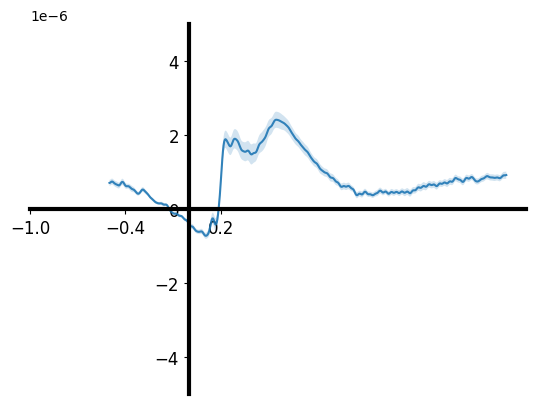

In [5]:
times = np.linspace(ERP_TMIN, ERP_TMAX, erp_across_subjects[0].shape[0])
y_min = -5e-6 
y_max = 5e-6  
plot_erp_results(erp_across_subjects, times, ylim=[y_min, y_max],labelpad=25)

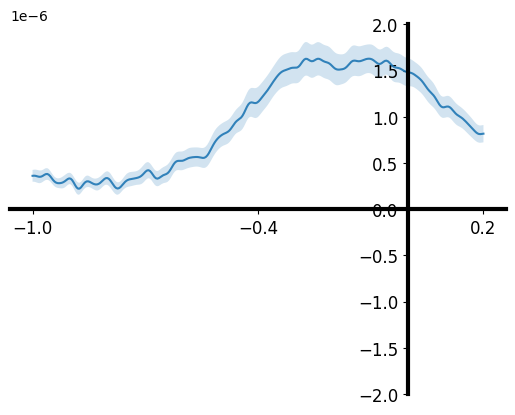

In [6]:
times = np.linspace(RESP_PRE, RESP_POST, erp_response_locked_across_subjects[0].shape[0])
y_min = -2e-6 
y_max = 2e-6  
plot_erp_results(erp_response_locked_across_subjects, times, ylim=[y_min, y_max],labelpad=25)